In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Data

In [5]:
import os
import pandas as pd

file_path = os.path.join(
    os.path.expanduser("~"),
    "Desktop",
    "Financial Data Analyst",
    "Financial-Analytics",
    "Data",
    "Budget_vs_Actual_Data.xlsx",
)

df = pd.read_excel(file_path)
df

,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID
0,2023-05-11,Sales,Travel,North,126096,43048,Card,TXN100000
1,2023-11-11,Marketing,Salaries,East,19702,87896,Bank Transfer,TXN100001
2,2021-05-02,IT,Training,Central,108523,103632,Card,TXN100002
3,2022-04-12,Marketing,Salaries,North,114711,105574,Cash,TXN100003
4,2021-11-27,Sales,Utilities,Central,121895,64314,UPI,TXN100004
...,...,...,...,...,...,...,...,...
10005,2022-04-18,Marketing,Marketing,South,23229,89695,Bank Transfer,TXN108517
10006,2021-05-12,Sales,Infrastructure,South,28919,65335,Card,TXN102041
10007,2021-08-23,Sales,Utilities,East,82957,72156,UPI,TXN101989
10008,2022-01-03,Finance,Infrastructure,North,68546,91058,Cash,TXN101933


# Inspect the Data

In [6]:
df.head()

,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID
0,2023-05-11,Sales,Travel,North,126096,43048,Card,TXN100000
1,2023-11-11,Marketing,Salaries,East,19702,87896,Bank Transfer,TXN100001
2,2021-05-02,IT,Training,Central,108523,103632,Card,TXN100002
3,2022-04-12,Marketing,Salaries,North,114711,105574,Cash,TXN100003
4,2021-11-27,Sales,Utilities,Central,121895,64314,UPI,TXN100004


In [7]:
df.shape

(10010, 8)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10010 entries, 0 to 10009
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            10010 non-null  datetime64[us]
 1   Department      10009 non-null  str           
 2   Category        10009 non-null  str           
 3   Region          10007 non-null  str           
 4   Budget Amount   10010 non-null  int64         
 5   Actual Amount   10010 non-null  int64         
 6   Payment Method  10010 non-null  str           
 7   Transaction ID  10007 non-null  str           
dtypes: datetime64[us](1), int64(2), str(5)
memory usage: 970.5 KB


In [9]:
df.describe()

,Date,Budget Amount,Actual Amount
count,10010,10010.000000,10010.000000
mean,2022-07-08 14:11:29.070929,79531.584316,89031.239261
min,2021-01-01 00:00:00,10005.000000,8002.000000
25%,2021-10-08 00:00:00,44379.000000,48570.250000
50%,2022-07-12 00:00:00,79515.500000,89188.000000
75%,2023-04-09 00:00:00,114575.250000,130586.000000
max,2023-12-31 00:00:00,149992.000000,169973.000000
std,NaN,40490.798172,46947.492216


# Check Missing Values

In [10]:
df.isnull().sum()

Date              0
Department        1
Category          1
Region            3
Budget Amount     0
Actual Amount     0
Payment Method    0
Transaction ID    3
dtype: int64

# Check Duplicates:

In [11]:
df.duplicated().sum()

np.int64(10)

# Check Unique Values:

In [12]:
df["Department"].unique()

<ArrowStringArray>
['Sales', 'Marketing', 'IT', 'Finance', 'HR', 'Operations', nan]
Length: 7, dtype: str

In [13]:
df["Category"].unique()

<ArrowStringArray>
[        'Travel',       'Salaries',       'Training',      'Utilities',
      'Marketing', 'Infrastructure',              nan]
Length: 7, dtype: str

In [14]:
df["Region"].unique()

<ArrowStringArray>
['North', 'East', 'Central', 'West', 'South', nan]
Length: 6, dtype: str

In [15]:
df["Payment Method"].unique()

<ArrowStringArray>
['Card', 'Bank Transfer', 'Cash', 'UPI']
Length: 4, dtype: str

# Cleaning Of Data

1.REMOVE DUPLICATES

In [16]:
df=df.drop_duplicates()

"Removed 10 exact duplicate rows (~0.1% of the dataset) caused by extraction/export redundancy to prevent double-counting in financial totals and variances."

2.CATEGORICAL FIELDS-

In [17]:
df["Department"]=df["Department"].fillna("Unknown")

In [18]:
df["Category"]=df["Category"].fillna("Unknown")

In [19]:
df["Region"]=df["Region"].fillna("Unknown")

In [20]:
df["Transation ID"]=df["Transaction ID"].fillna("Unknown")

3.CONVERR DATE-

In [21]:
df["Date"]=pd.to_datetime(df["Date"])
df["Date"]

0      2023-05-11
1      2023-11-11
2      2021-05-02
3      2022-04-12
4      2021-11-27
          ...    
9995   2022-09-05
9996   2022-11-28
9997   2022-08-26
9998   2021-09-05
9999   2021-12-25
Name: Date, Length: 10000, dtype: datetime64[us]

4.CHECK FINANCIAL COLUMNS

In [22]:
df["Budget Amount"]=pd.to_numeric(df["Budget Amount"],errors="coerce")
df["Budget Amount"].dtype

dtype('int64')

In [23]:
df["Actual Amount"]=pd.to_numeric(df["Actual Amount"],errors="coerce")
df["Actual Amount"].dtype

dtype('int64')

# Create Financial Variables

1.VARIANCE

In [24]:
df["Variance"]=(df["Actual Amount"]-df["Budget Amount"])
df["Variance"]

0      -83048
1       68194
2       -4891
3       -9137
4      -57581
        ...  
9995    16920
9996   -79997
9997    -3465
9998   -34537
9999   -77680
Name: Variance, Length: 10000, dtype: int64

2.VARIANCE %

In [25]:
df["Variance %"]=(df["Variance"]/df["Budget Amount"])
df["Variance %"]

0      -0.658609
1       3.461273
2      -0.045069
3      -0.079652
4      -0.472382
          ...   
9995    0.281105
9996   -0.648715
9997   -0.032409
9998   -0.345802
9999   -0.670406
Name: Variance %, Length: 10000, dtype: float64

3. BUDGET UTILIZATION-

In [26]:
df["Budget Utilizaton %"]=(df["Actual Amount"]/df["Budget Amount"]) * 100

4. ADD COLUMN YEAR-

In [27]:
df["Year"]=df["Date"].dt.year
df["Year"]

0       2023
1       2023
2       2021
3       2022
4       2021
        ... 
9995    2022
9996    2022
9997    2022
9998    2021
9999    2021
Name: Year, Length: 10000, dtype: int32

5. ADD COLUMN MONTH-

In [28]:
df["Month"]=df["Date"].dt.month
df["Month"]

0        5
1       11
2        5
3        4
4       11
        ..
9995     9
9996    11
9997     8
9998     9
9999    12
Name: Month, Length: 10000, dtype: int32

6. ADD COLUMN MONTH NAME-

In [29]:
df["Month_Name"]=df["Date"].dt.month_name()
df["Month_Name"]

0             May
1        November
2             May
3           April
4        November
          ...    
9995    September
9996     November
9997       August
9998    September
9999     December
Name: Month_Name, Length: 10000, dtype: str

# Understand Favourable Vs Unfavourable Variance

1. FOR EXPENSES-

Actual > Budget =Unfavourable (BECAUSE YOU SPEND MORE THEN PLANNED)

Actual < Budget= Favourable (BECAUSE YOU SPENT LESS THEN PLANNED)

2. CREATE VARIANCE STATUS-

In [30]:
df["Variance Status"]=np.where(df["Variance"]>0,"Unfavorable","Favorable")
df["Variance Status"]

0         Favorable
1       Unfavorable
2         Favorable
3         Favorable
4         Favorable
           ...     
9995    Unfavorable
9996      Favorable
9997      Favorable
9998      Favorable
9999      Favorable
Name: Variance Status, Length: 10000, dtype: str

Be careful: this interpretation is appropriate for **expense** variance. For revenue, higher actual revenue than budget is generally favorable.

# Phase 4 -Exploratory Data Analysis

# Which Department has the highest actual spending ?

In [31]:
department_actual=(
    df.groupby("Department")["Actual Amount"]
        .sum()
        .sort_values(ascending=False)
        )

In [32]:
department_actual

Department
HR            155439763
Marketing     151816098
Sales         151344999
Operations    147803987
Finance       144084529
IT            139663026
Unknown          114627
Name: Actual Amount, dtype: int64

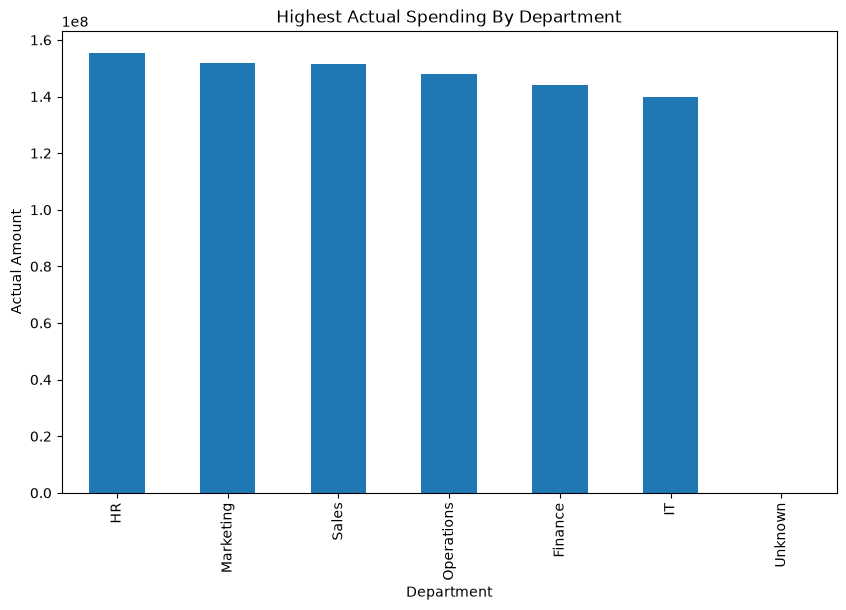

In [33]:
department_actual.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Highest Actual Spending By Department")
plt.xlabel("Department")
plt.ylabel("Actual Amount")
plt.show()

# Which department has the largest variance ?

In [34]:
department_variance=(
    df.groupby("Department")["Variance"]
    .sum()
    .sort_values(ascending=False)
)

In [35]:
department_variance

Department
Marketing     19876619
HR            18068600
Sales         16642511
Operations    15181774
IT            13892025
Finance       11137380
Unknown          -1136
Name: Variance, dtype: int64

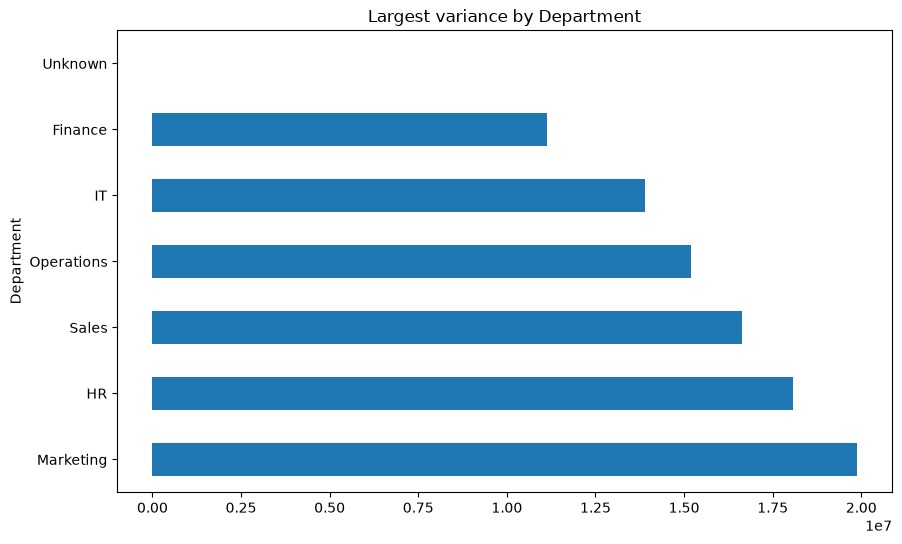

In [36]:
department_variance.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Largest variance by Department")
plt.show()

# Which Expense Category consumes the most Budget ?

In [37]:
category_actual=(
    df.groupby("Category")["Budget Amount"]
    .sum()
    .sort_values(ascending=False)
)

In [38]:
category_actual

Category
Travel            139968858
Utilities         137891618
Training          132399473
Marketing         130224132
Infrastructure    127813870
Salaries          127131160
Unknown               40145
Name: Budget Amount, dtype: int64

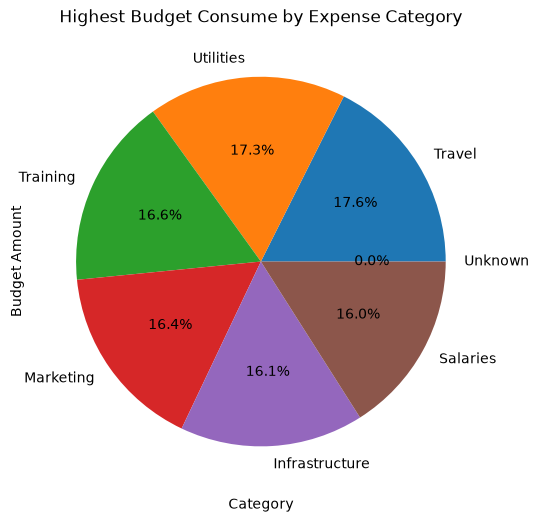

In [39]:

category_actual.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(10,6)
)

plt.title("Highest Budget Consume by Expense Category")
plt.xlabel("Category")
plt.ylabel("Budget Amount")
plt.show()

# What is the monthly spnding trend?

In [40]:
monthly_spending=(
    df.groupby(df["Date"].dt.to_period("M")
              )["Actual Amount"]
    .sum()
)

In [41]:
monthly_spending

Date
2021-01    24913213
2021-02    20632263
2021-03    24295909
2021-04    24364104
2021-05    27250381
2021-06    22396228
2021-07    24685975
2021-08    25003789
2021-09    25829986
2021-10    22180032
2021-11    22968470
2021-12    22990736
2022-01    26727517
2022-02    21186138
2022-03    24891811
2022-04    24055215
2022-05    26605506
2022-06    24875581
2022-07    26115690
2022-08    26201877
2022-09    23615228
2022-10    26499256
2022-11    23619293
2022-12    28476038
2023-01    22556271
2023-02    22714535
2023-03    24144517
2023-04    29230433
2023-05    24725549
2023-06    23994290
2023-07    28433347
2023-08    25209565
2023-09    25829660
2023-10    24008371
2023-11    22933724
2023-12    26106531
Freq: M, Name: Actual Amount, dtype: int64

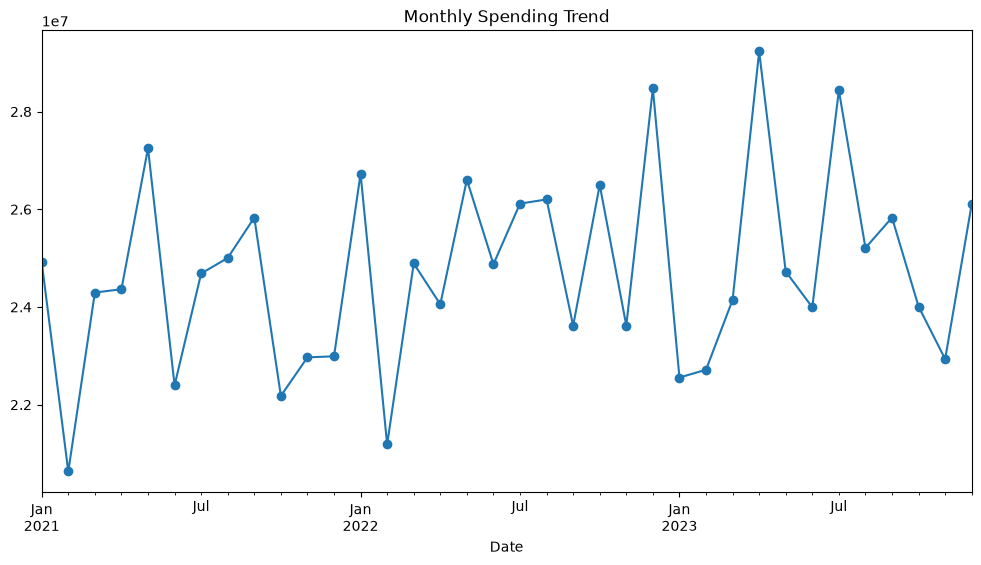

In [42]:
monthly_spending.plot(
    kind="line",
    figsize=(12,6),
    marker="o")
plt.title("Monthly Spending Trend")
plt.show()

In [45]:
pip install psycopg2-binary sqlalchemy

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ---------------------------

# Exporting Cleaned File-

In [50]:
from pathlib import Path

# 1. Automatically locate your Desktop directory
desktop_path = Path.home() / "Desktop" / "Budget_Actual_Clean.csv"

# 2. Export the DataFrame
df.to_csv(desktop_path, index=False,encoding="utf-8")

print(f"Saved to: {desktop_path}")

Saved to: C:\Users\DHIRAJ PATIL\Desktop\Budget_Actual_Clean.csv
